In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
data = pd.read_csv("C:\Desktop\Desktop\python coding\covid_19_project\Covid_19_Clean_Complete (2).csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\shruthi\AppData\Local\Temp\ipykernel_11260\3389053607.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("C:\Desktop\Desktop\python coding\covid_19_project\Covid_19_Clean_Complete (2).csv")


In [11]:
data.head(1)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [13]:
data.rename(columns={'Province/State':'state','Country/Region':'country'}, inplace=True)

In [14]:
data['Date']=pd.to_datetime(data['Date'])

In [15]:
data['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 49068 entries, 0 to 49067
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
49068 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 383.5 KB


In [16]:
data.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [17]:
data.isnull().sum()

state         34404
country           0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [18]:
data['Date'].value_counts()

Date
2020-01-22    261
2020-05-30    261
2020-05-21    261
2020-05-22    261
2020-05-23    261
             ... 
2020-03-26    261
2020-03-27    261
2020-03-28    261
2020-03-29    261
2020-07-27    261
Name: count, Length: 188, dtype: int64

In [19]:
data['Date'].max()

Timestamp('2020-07-27 00:00:00')

In [20]:
top_data=data[data['Date'] == '2020-07-27']
top_data.head(5)

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


In [21]:
group= top_data.groupby('country')[['Confirmed',
                                    'Deaths','Recovered',
                                    'Active']].sum().reset_index()
group

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


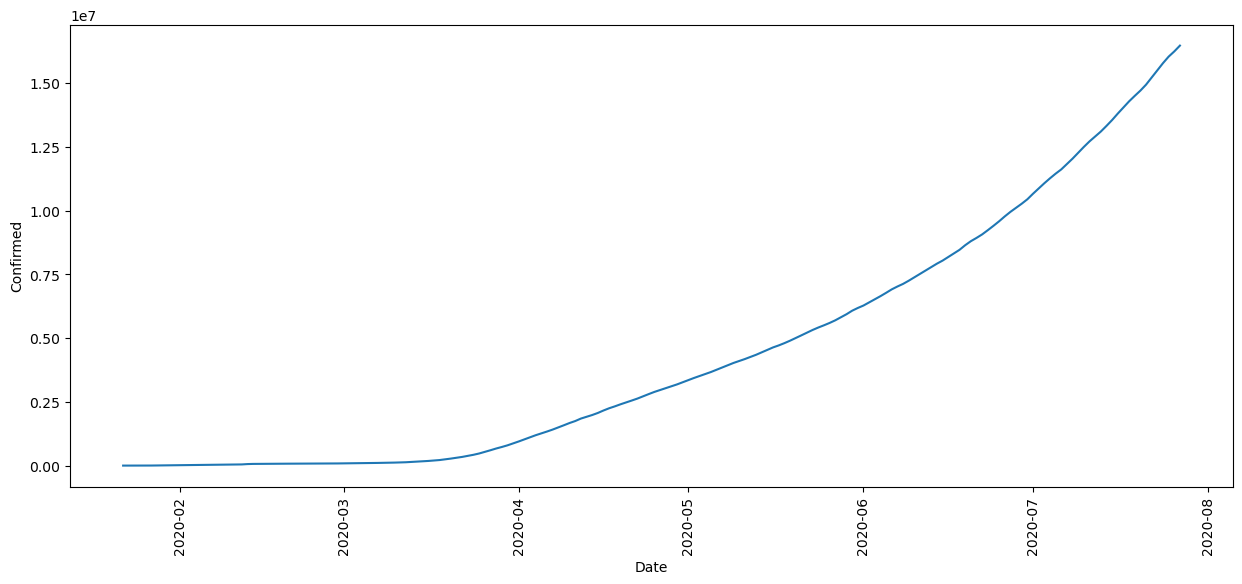

In [22]:
confirmed_cases = data.groupby('Date')['Confirmed'].sum().reset_index()
confirmed_cases

plt.figure(figsize=(15,6))
sns.lineplot(data=confirmed_cases,x='Date',y='Confirmed')
plt.xticks(rotation=90)
plt.show()

          Date  Recovered
0   2020-01-22         28
1   2020-01-23         30
2   2020-01-24         36
3   2020-01-25         39
4   2020-01-26         52
..         ...        ...
183 2020-07-23    8710969
184 2020-07-24    8939705
185 2020-07-25    9158743
186 2020-07-26    9293464
187 2020-07-27    9468087

[188 rows x 2 columns]


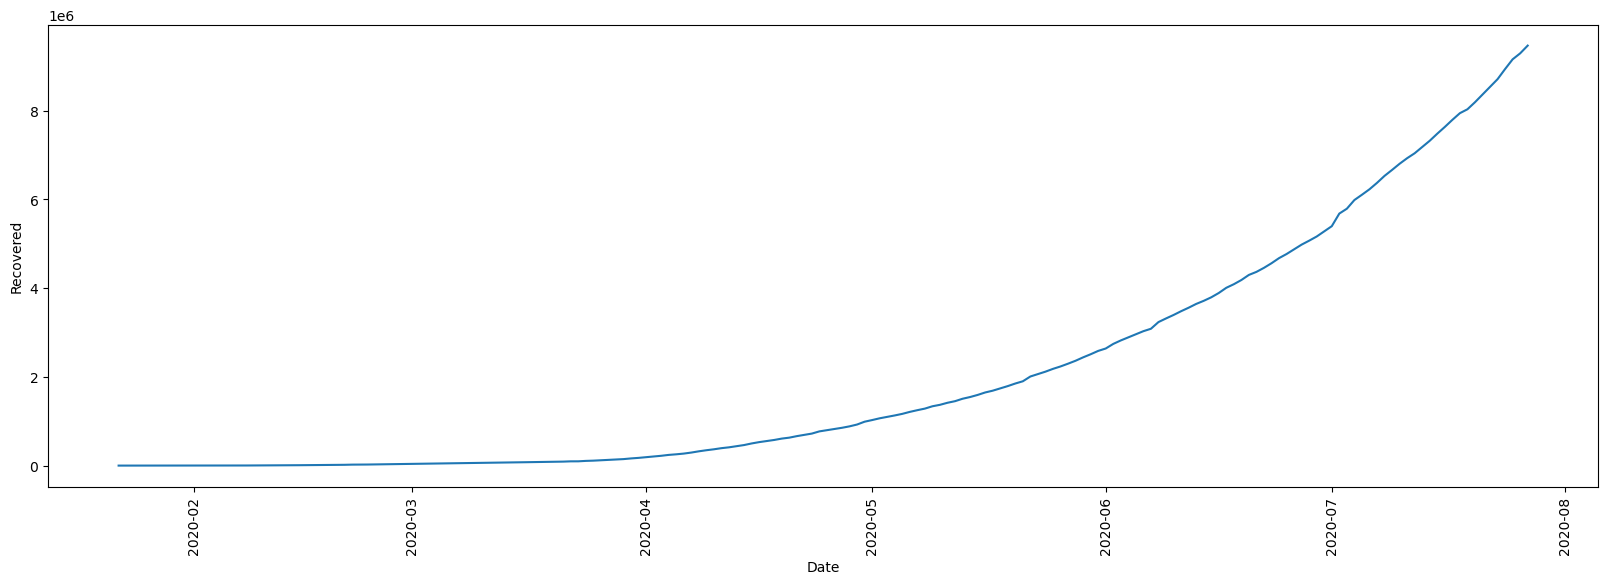

In [23]:
recovered_cases= data.groupby('Date')['Recovered'].sum().reset_index()
print(recovered_cases)

plt.figure(figsize=(20,6))
sns.lineplot(data=recovered_cases,x='Date',y='Recovered')
plt.xticks(rotation=90)
plt.show()

          Date  Deaths
0   2020-01-22      17
1   2020-01-23      18
2   2020-01-24      26
3   2020-01-25      42
4   2020-01-26      56
..         ...     ...
183 2020-07-23  633506
184 2020-07-24  639650
185 2020-07-25  644517
186 2020-07-26  648621
187 2020-07-27  654036

[188 rows x 2 columns]


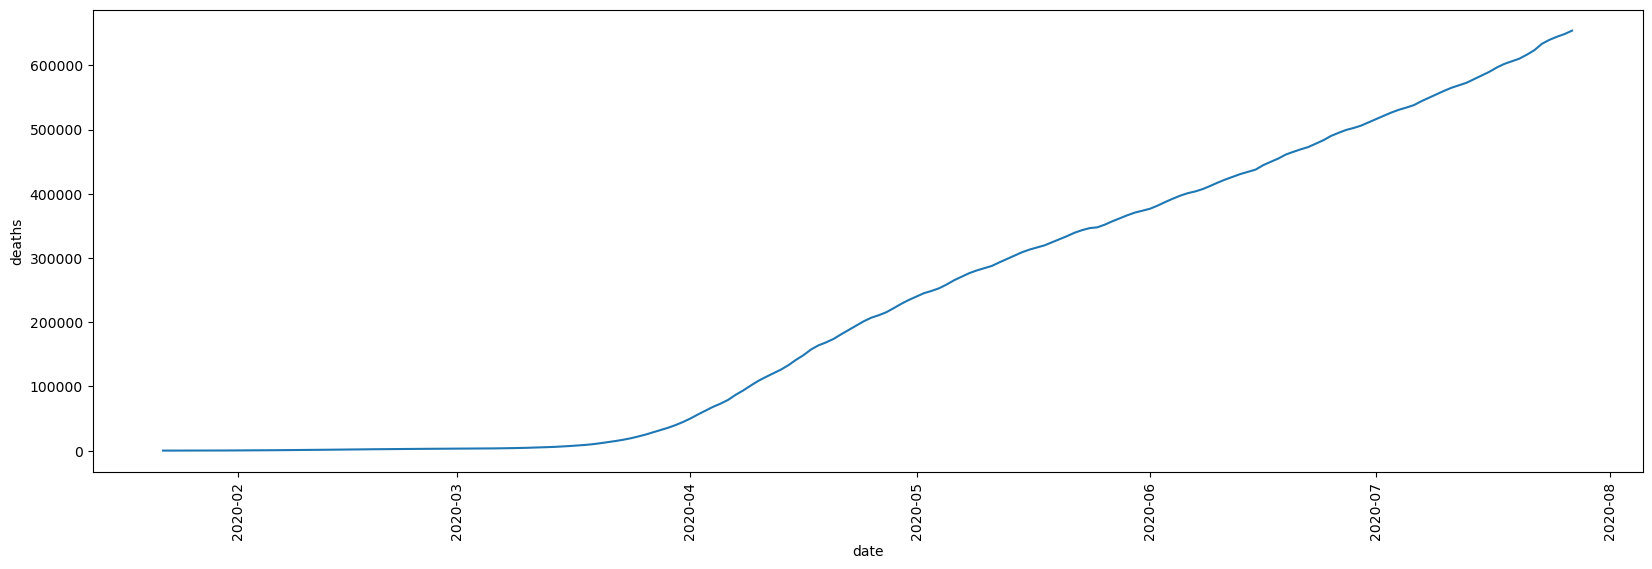

In [24]:
death_cases = data.groupby('Date')['Deaths'].sum().reset_index()
print(death_cases)

plt.figure(figsize=(20,6))
sns.lineplot(data=death_cases,x='Date',y='Deaths')
plt.xlabel("date")
plt.ylabel("deaths")
plt.xticks(rotation=90)
plt.show()

          Date   Active
0   2020-01-22      510
1   2020-01-23      606
2   2020-01-24      879
3   2020-01-25     1353
4   2020-01-26     2010
..         ...      ...
183 2020-07-23  6166006
184 2020-07-24  6212290
185 2020-07-25  6243930
186 2020-07-26  6309711
187 2020-07-27  6358362

[188 rows x 2 columns]


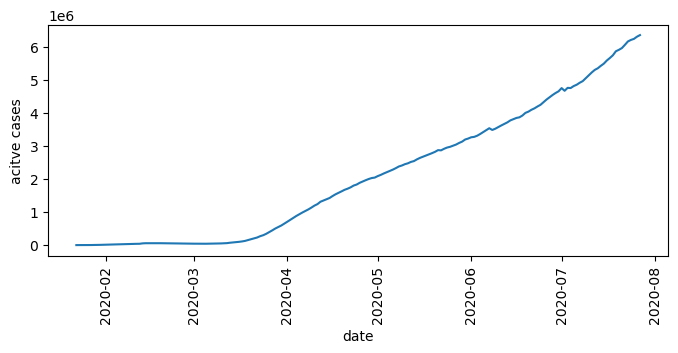

In [25]:
active_cases = data.groupby('Date')['Active'].sum().reset_index()
print(active_cases)

plt.figure(figsize=(8,3))
sns.lineplot(data = active_cases, y ='Active', x = 'Date')
plt.xlabel("date")
plt.ylabel("acitve cases")
plt.xticks(rotation =90)
plt.show()

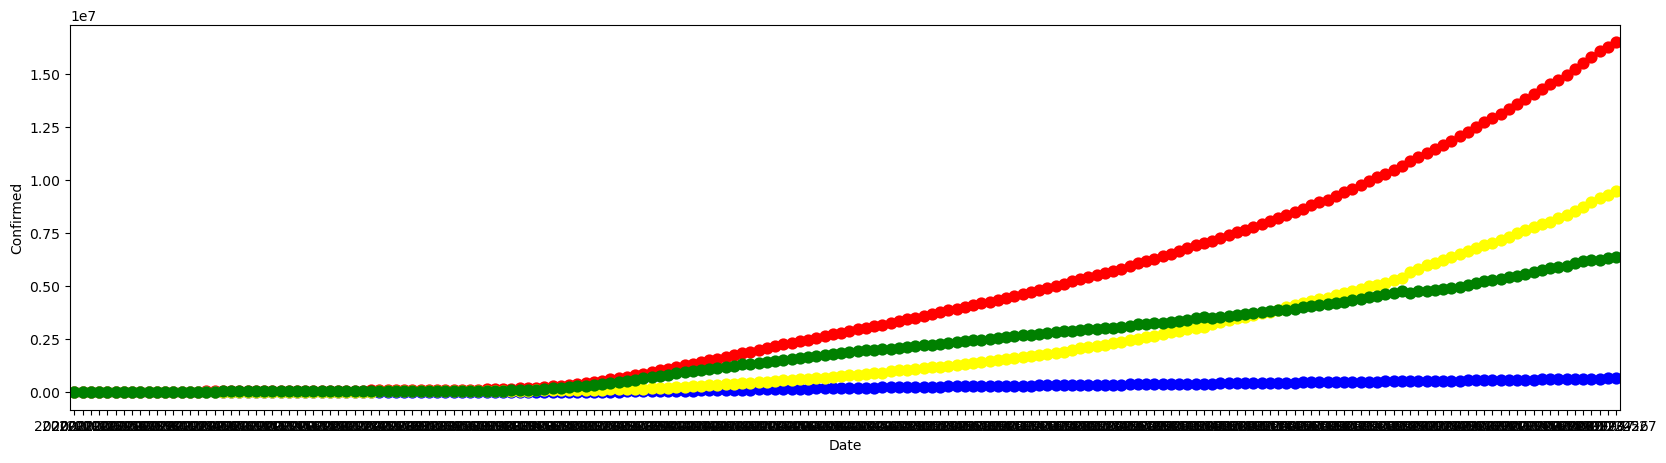

In [26]:
plt.figure(figsize=(20,5))
sns.pointplot(data=confirmed_cases,x='Date',y='Confirmed',color='Red')
sns.pointplot(data=death_cases,x='Date',y='Deaths',color='Blue')
sns.pointplot(data=recovered_cases,x='Date',y='Recovered',color='Yellow')
sns.pointplot(data=active_cases,x='Date',y='Active',color='Green')
plt.show()

top 10 countries with the most recovered cases

   country  Recovered
0       US   56353416
1   Brazil   54492873
2   Russia   25120448
3    India   23783720
4  Germany   17107839
5    Italy   15673910
6     Iran   15200895
7    Spain   15093583
8   Turkey   13345389
9    Chile   13292593


Text(0.5, 1.0, 'top countries with most recovered cases')

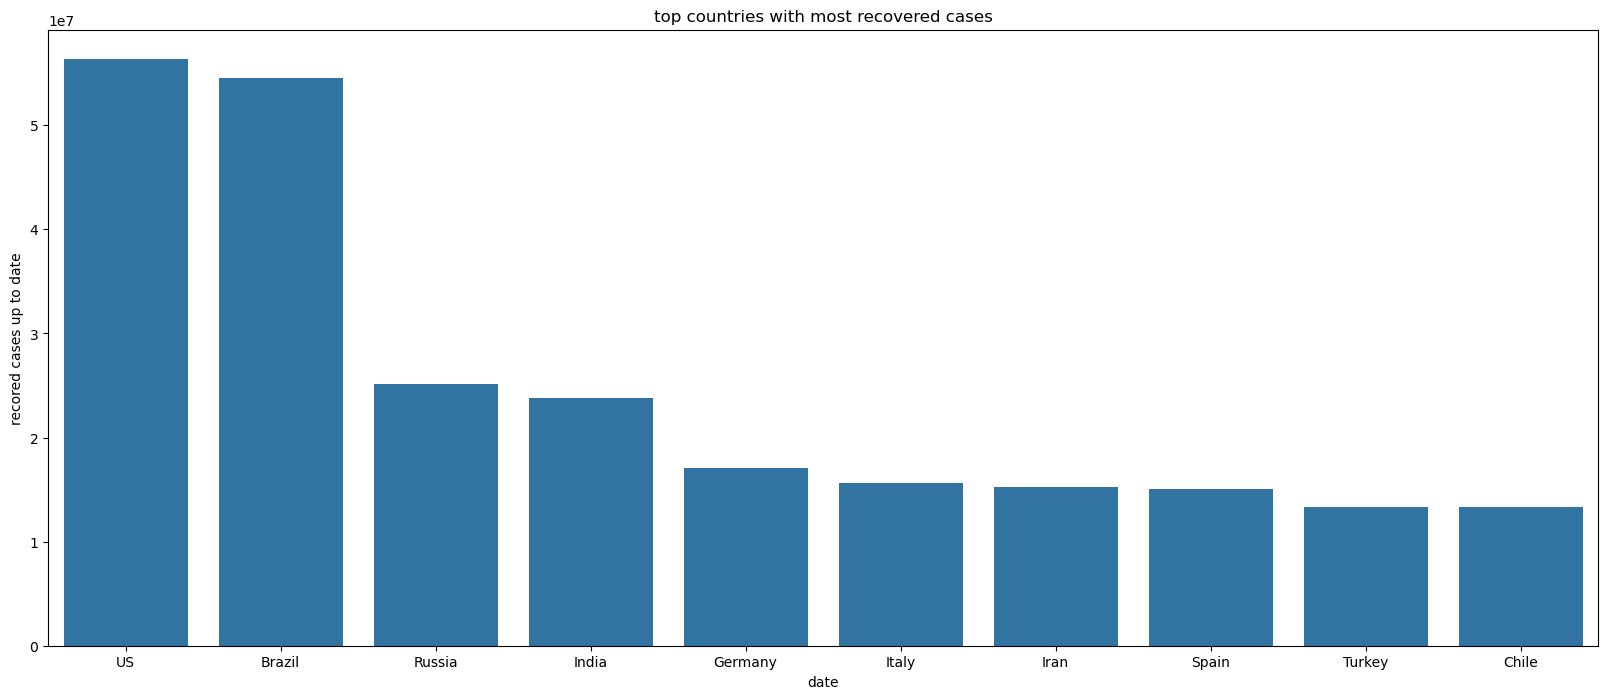

In [27]:
top_countries = data.groupby('country')['Recovered'].sum().sort_values(
    ascending=False).head(10).reset_index()
print(top_countries)

plt.figure(figsize=(20,8))
sns.barplot(data = top_countries,x='country',y='Recovered')
plt.xlabel("date")
plt.ylabel("recored cases up to date")
plt.title("top countries with most recovered cases")

countries with highest death rates

          country    Deaths
0              US  11011411
1  United Kingdom   3997775
2          Brazil   3938034
3           Italy   3707717
4          France   3048524
5           Spain   3033030
6          Mexico   1728277
7           India   1111831
8            Iran   1024136
9         Belgium    963679


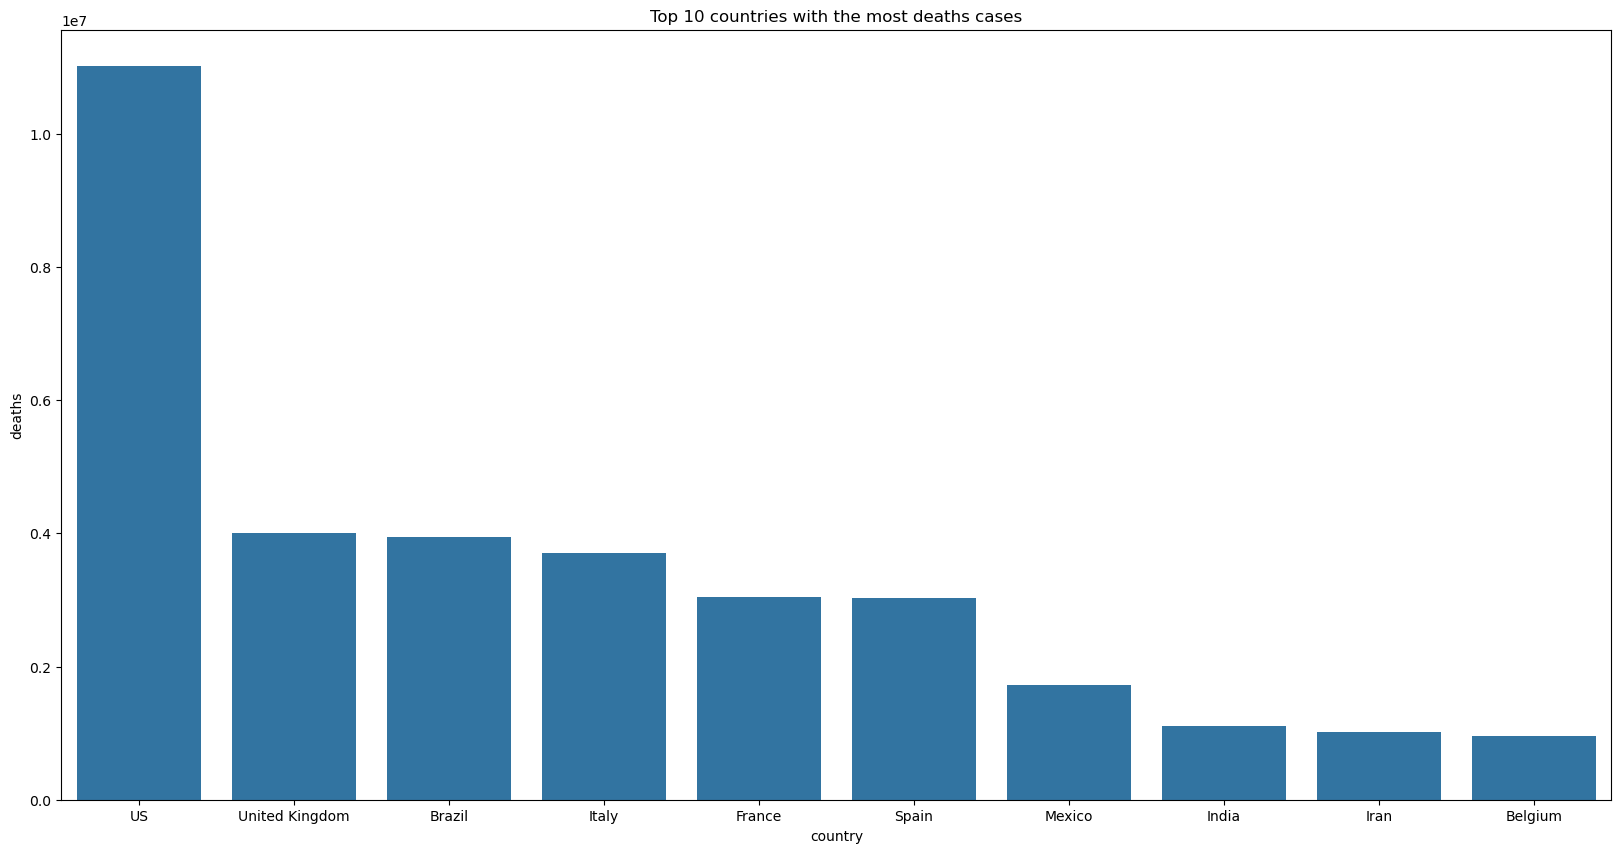

In [28]:
top_10deaths =data.groupby('country')['Deaths'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_10deaths)
#Visualising death cases
plt.figure(figsize=(20,10))
sns.barplot(data=top_10deaths,x='country',y='Deaths')
plt.title("Top 10 countries with the most deaths cases")
plt.xlabel("country")
plt.ylabel("deaths")

plt.show()


top coubtries with most active cases


          country     Active
0              US  156981121
1          Brazil   31094060
2  United Kingdom   22624595
3          Russia   19668578
4           India   15987913
5          France   10980287
6           Spain    9277432
7          Canada    8656985
8            Peru    7748957
9           Italy    7363518


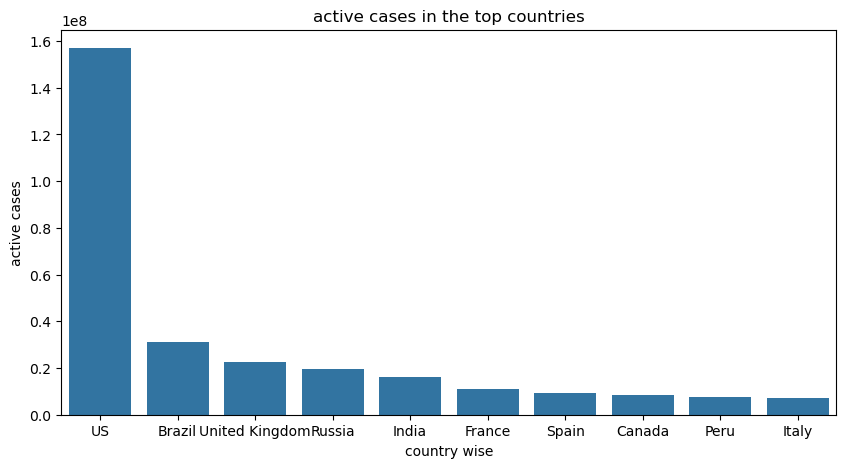

In [29]:
top_10active = data.groupby('country')['Active'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_10active)

plt.figure(figsize=(10,5))
sns.barplot(data = top_10active, x ='country',y='Active')
plt.xlabel("country wise")
plt.ylabel("active cases")
plt.title("active cases in the top countries")
plt.show()

country based analysis

In [30]:
# datasets for india
India = data[data['country']=='India']
India = India.groupby("Date")[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
print(India)

          Date  Confirmed  Deaths  Recovered  Active
0   2020-01-22          0       0          0       0
1   2020-01-23          0       0          0       0
2   2020-01-24          0       0          0       0
3   2020-01-25          0       0          0       0
4   2020-01-26          0       0          0       0
..         ...        ...     ...        ...     ...
183 2020-07-23    1288108   30601     817209  440298
184 2020-07-24    1337024   31358     849432  456234
185 2020-07-25    1385635   32060     885573  468002
186 2020-07-26    1435616   32771     917568  485277
187 2020-07-27    1480073   33408     951166  495499

[188 rows x 5 columns]


In [31]:
# datasets for united states
US = data[data['country']=='US']
US= US.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
print(US)

          Date  Confirmed  Deaths  Recovered   Active
0   2020-01-22          1       0          0        1
1   2020-01-23          1       0          0        1
2   2020-01-24          2       0          0        2
3   2020-01-25          2       0          0        2
4   2020-01-26          5       0          0        5
..         ...        ...     ...        ...      ...
183 2020-07-23    4038816  144430    1233269  2661117
184 2020-07-24    4112531  145560    1261624  2705347
185 2020-07-25    4178970  146465    1279414  2753091
186 2020-07-26    4233923  146935    1297863  2789125
187 2020-07-27    4290259  148011    1325804  2816444

[188 rows x 5 columns]


In [32]:
# create dataset for china
china = data[data['country']=='China']
china =china.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
china

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


compare india , us, china on the basis of their recovered cases

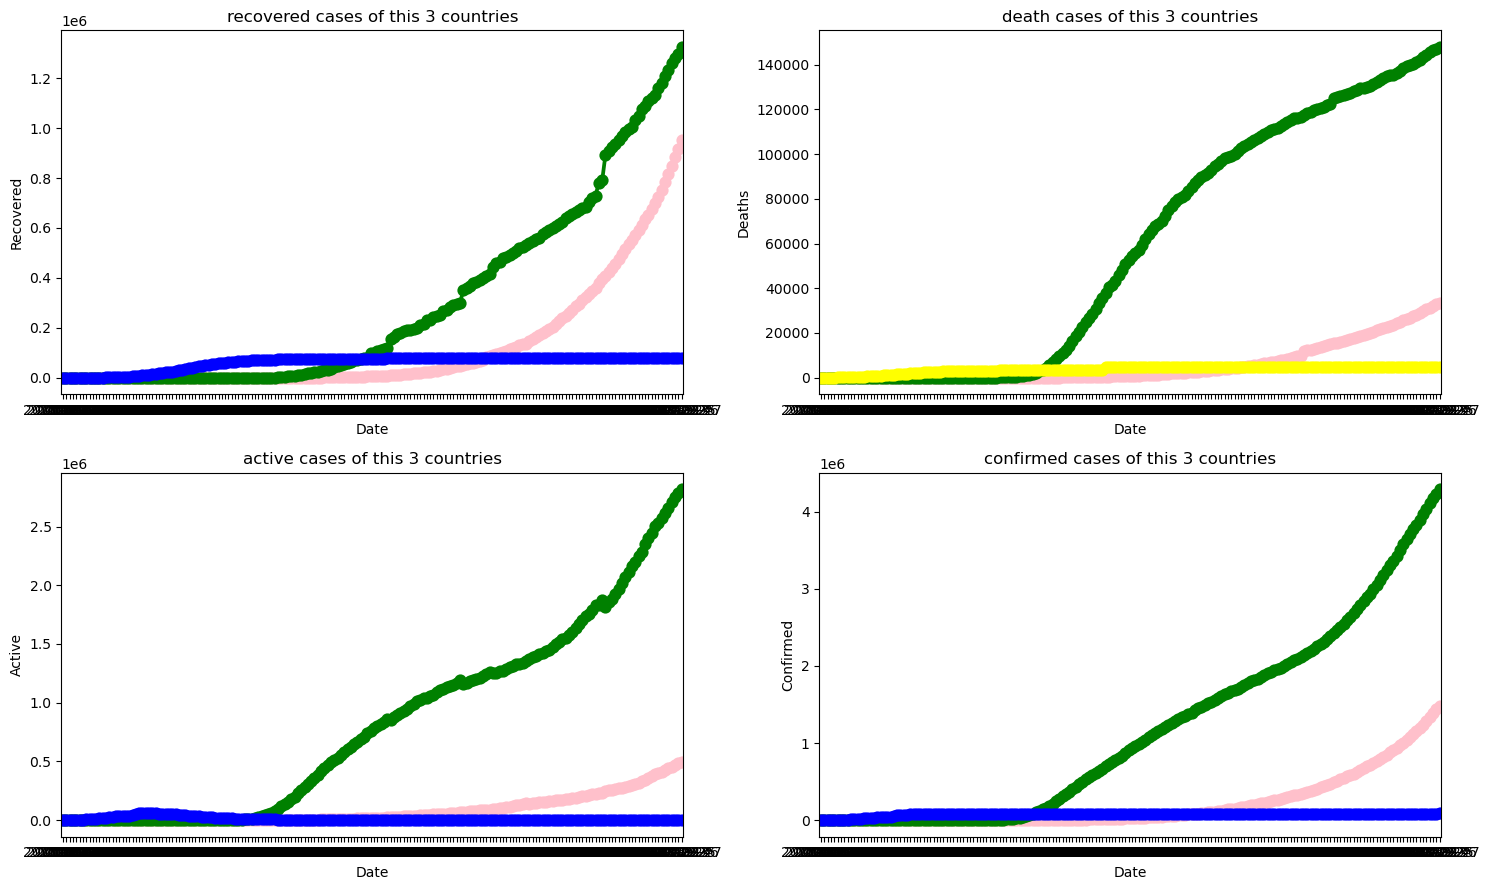

In [33]:
# visual representation
plt.figure(figsize=(15,9))
plt.subplot(2,2,1)
sns.pointplot(data = India, x ='Date', y ='Recovered', color='Pink')
sns.pointplot(data =US, x ='Date', y='Recovered', color ='Green')
sns.pointplot(data =china, x ='Date', y='Recovered', color ='Blue')
plt.tight_layout()
plt.title("recovered cases of this 3 countries")


plt.subplot(2,2,2)
sns.pointplot(data = India, x ='Date', y ='Deaths', color='Pink')
sns.pointplot(data =US, x ='Date', y='Deaths', color ='Green')
sns.pointplot(data =china, x ='Date', y='Deaths', color ='Yellow')
plt.tight_layout()
plt.title("death cases of this 3 countries")

plt.subplot(2,2,3)
sns.pointplot(data = India, x ='Date', y ='Active', color='Pink')
sns.pointplot(data =US, x ='Date', y='Active', color ='Green')
sns.pointplot(data =china, x ='Date', y='Active', color ='Blue')
plt.tight_layout()
plt.title("active cases of this 3 countries")


plt.subplot(2,2,4)
sns.pointplot(data = India, x ='Date', y ='Confirmed', color='Pink')
sns.pointplot(data =US, x ='Date', y='Confirmed', color ='Green')
sns.pointplot(data =china, x ='Date', y='Confirmed', color ='Blue')
plt.tight_layout()
plt.title("confirmed cases of this 3 countries")
plt.show()

model building

In [34]:
!pip install Prophet

In [40]:
confirmed_cases = data.groupby(['Date']).sum()['Confirmed'].reset_index()
# print(confirmed_cases

recovered_cases = data.groupby(['Date']).sum()['Recovered'].reset_index()

death_cases = data.groupby(['Date']).sum()['Deaths'].reset_index()

active_cases = data.groupby(['Date']).sum()['Active'].reset_index()

In [ ]:
confirmed_cases.columns=['ds','y']
 # these are the requirements that columns must be in this format
print(confirmed_cases)
# recovered_cases.columns=['ds','y']

# active_cases.columns=['ds','y']

# death_cases.columns=['ds','y']

            ds         y
0   2020-01-22       555
1   2020-01-23       654
2   2020-01-24       941
3   2020-01-25      1434
4   2020-01-26      2118
..         ...       ...
183 2020-07-23  15510481
184 2020-07-24  15791645
185 2020-07-25  16047190
186 2020-07-26  16251796
187 2020-07-27  16480485

[188 rows x 2 columns]


17:07:46 - cmdstanpy - INFO - Chain [1] start processing
17:07:46 - cmdstanpy - INFO - Chain [1] done processing


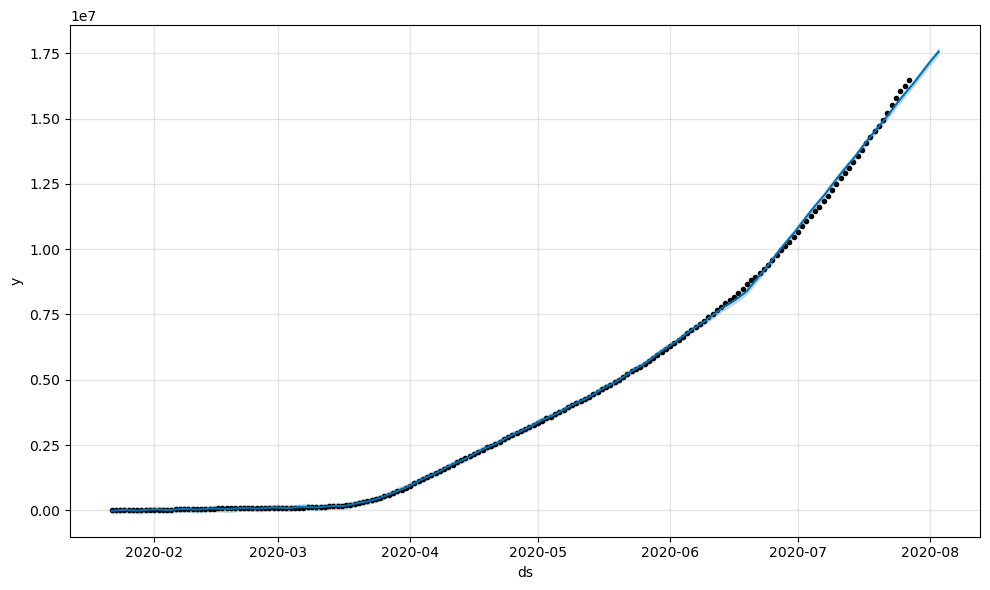

In [ ]:
from prophet import Prophet
model = Prophet()

model.fit(confirmed_cases)
future1 = model.make_future_dataframe(periods=7)
forecast1 =model.predict(future1)
forecast1

model.plot(forecast1)
plt.show()

ds is the timestamp for which prediction made
yhat -> the predicted value (forecast output) for the corresponding data
yhat lower or upper-> ia the bounds of the uncertainity interval for the forecast
trend->the estimeed the trend component

In [56]:
data['country'].isnull().sum()

0

In [75]:
import plotly
import plotly.express as pt

world = data.groupby('country')[['Confirmed','Active',
                                 'Recovered','Deaths']].sum().reset_index()
fig = pt.choropleth(world, locations='country',
                    locationmode='country names',
                    color='Recovered', hover_name='country',
                    color_continuous_scale='Greens',
                    title='Global Active cases',
                    height=900,
                    width=1200)
fig.update_layout(
    template='plotly_dark',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="white"
    )
)
fig.show()